In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC



In [7]:
dataset = pd.read_csv("spam.csv",encoding='latin')

In [9]:

dataset.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [11]:
if 'v1' in dataset.columns and 'v2' in dataset.columns:
  dataset = dataset.rename(columns={'v1': 'Category', 'v2': 'Message'})
dataset.head()

,Category,Message,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


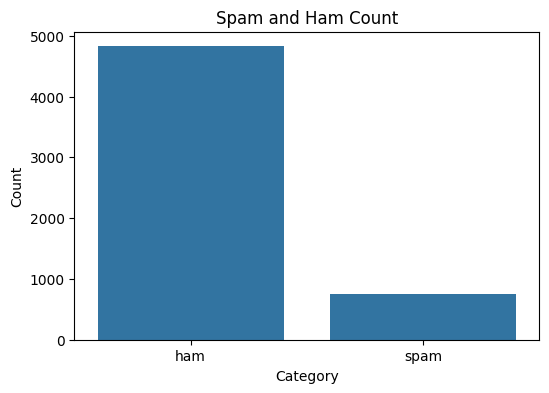

In [12]:
X = dataset['Category'].values
y = dataset['Message'].values
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=dataset)
plt.title("Spam and Ham Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.savefig("exercise3a.png")
plt.show()


In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0)

cv = CountVectorizer()
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

In [14]:
print(classifier.score(X_test,y_test))

0.003587443946188341
